# Strategy A — VIX Term-Structure Carry

Short front-month VX, long second-month VX, dollar-neutral, rolled 5 trading days before front expiry, 1 bp per leg traded at each roll. PnL uses splice-free held-contract returns (see `vrp.data.vx_futures`). This notebook regenerates the tables and figures for Strategy A.

**Train window:** 2013-01-01 → 2018-12-31. **Test window:** 2019-01-01 → 2024-12-31. Test parameters are frozen from the training window; nothing is tuned on the test set.


In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd, matplotlib.pyplot as plt
from vrp.data.vx_futures import load_vx_continuous
from vrp.strategies.strategy_a import run_strategy_a
from vrp.report.metrics import summary, drawdown_series
from vrp.report.regimes import regime_metrics

In [2]:
vx = load_vx_continuous('2013-01-01', '2024-12-31')
result = run_strategy_a(vx)
ret = result['daily_return']
train_ret = ret.loc['2013-01-01':'2018-12-31']
test_ret  = ret.loc['2019-01-01':'2024-12-31']

In [3]:
pd.DataFrame({'train': summary(train_ret), 'test': summary(test_ret)}).round(4)

,train,test
ann_return,0.0096,0.1163
ann_vol,0.1334,0.1320
sharpe,0.0723,0.8811
sortino,0.1708,1.1534
max_drawdown,-0.2294,-0.1968
drawdown_duration_days,354.0000,362.0000
skew,-3.4281,-1.4530
kurtosis,40.6844,6.3728
p01,-0.0274,-0.0274
p05,-0.0122,-0.0137


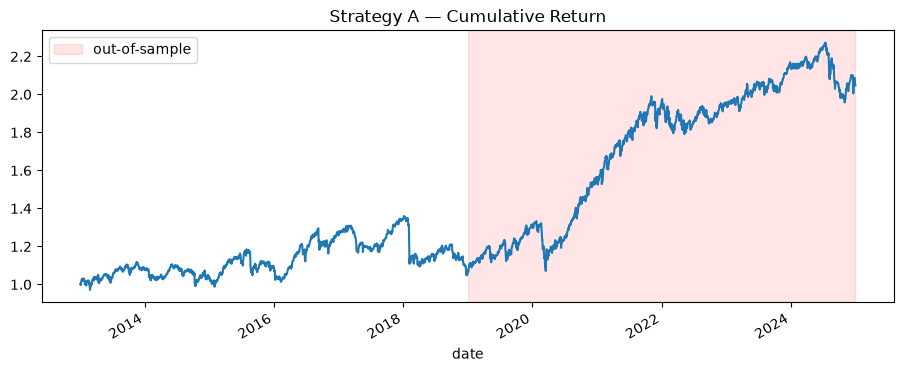

In [4]:
(1 + ret).cumprod().plot(figsize=(11,4), title='Strategy A — Cumulative Return')
plt.axvspan('2019-01-01', '2024-12-31', alpha=0.1, color='red', label='out-of-sample')
plt.legend(); plt.show()

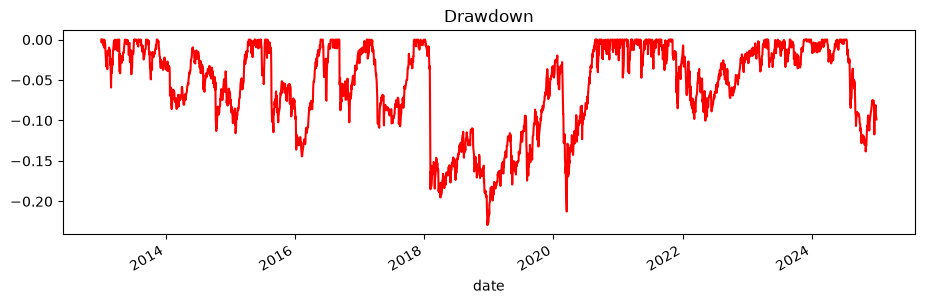

In [5]:
drawdown_series(ret).plot(figsize=(11,3), title='Drawdown', color='red'); plt.show()

In [6]:
pd.DataFrame(regime_metrics(test_ret)).T.round(4)

,n_days,cum_return,worst_day,max_drawdown
gfc_2008,0.0,NaN,NaN,NaN
vol_spike_2015,0.0,NaN,NaN,NaN
volmageddon_2018,0.0,NaN,NaN,NaN
covid_2020,50.0,-0.096,-0.0450,-0.1841
bear_2022,209.0,-0.031,-0.0326,-0.0937
